# Testing OT on Binned Bulk OT
Now that we confirmed that OT works on very simple, synthetic contact maps, we'll move to formats more accurate to actual Hi-C data. For this, we'll use bulk data for mouse chromosome 1, bin it to smaller sizes to facilitate quick computation time, write a function to add more and more noise to mimick the similarity parameter from before and finally check if exact OT and UOT still behave as expected.

## Importing Data

In [6]:
### Importing Cooler Files ###
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import numpy as np
import matplotlib.pyplot as plt
import ot
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, visualize_synthetic_maps, generate_related_contact_map

# Importing data
data_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/taghic'
coolers = import_cool_dir(data_dir, 1_000_000)

# Extracting chromosome 1
chr1s = []
for clr in coolers:
    chr1s.append(fetch_region(clr, '1'))

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
### Writing binning function
def bin_contact_map(matrix : np.ndarray, bin_size : int):
    '''
        Bins a Hi-C-like contact map to smaller total bin numbers
        by binning bin_size bins together.

        Parameters 
        ----------
        matrix : np.ndarray
            Square matrix to be binned.
        bin_size : int
            Number of bins that will become one bin on one axis.
            Any bins outside of this range will be deleted.
        
        Returns
        -------
        binned_matrix : np.ndarray
            Rebinned matrix.
    '''
    # Assure square matrix
    n = matrix.shape[0]
    if n != matrix.shape[1]:
        raise ValueError("Input matrix is not symmetrical!")
    
    # Assure valid bin_size
    if bin_size < 0:
        raise ValueError(f"Invalid bin_size: {bin_size}")
    
    # Binning
    m = n // bin_size
    binned_matrix = matrix[:m*bin_size, :m*bin_size].reshape(m, bin_size, m, bin_size).sum(axis=(1, 3))

    return binned_matrix

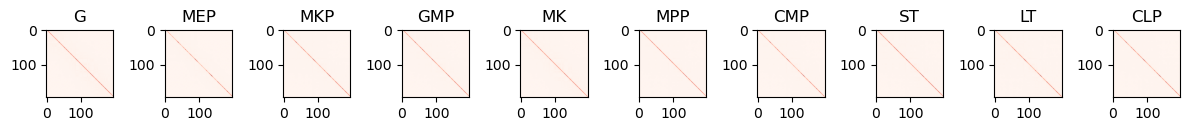

(<Figure size 1200x400 with 10 Axes>,
 array([<Axes: title={'center': 'G'}>, <Axes: title={'center': 'MEP'}>,
        <Axes: title={'center': 'MKP'}>, <Axes: title={'center': 'GMP'}>,
        <Axes: title={'center': 'MK'}>, <Axes: title={'center': 'MPP'}>,
        <Axes: title={'center': 'CMP'}>, <Axes: title={'center': 'ST'}>,
        <Axes: title={'center': 'LT'}>, <Axes: title={'center': 'CLP'}>],
       dtype=object))

In [8]:
### Visualizing contact maps ###
titles = ["G", "MEP", "MKP", "GMP", "MK", "MPP", "CMP", "ST", "LT", "CLP"]
visualize_synthetic_maps(chr1s, titles)

## Exact OT

### Binning to 4 Mb

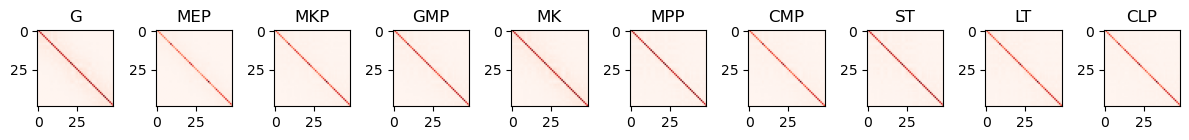

(<Figure size 1200x400 with 10 Axes>,
 array([<Axes: title={'center': 'G'}>, <Axes: title={'center': 'MEP'}>,
        <Axes: title={'center': 'MKP'}>, <Axes: title={'center': 'GMP'}>,
        <Axes: title={'center': 'MK'}>, <Axes: title={'center': 'MPP'}>,
        <Axes: title={'center': 'CMP'}>, <Axes: title={'center': 'ST'}>,
        <Axes: title={'center': 'LT'}>, <Axes: title={'center': 'CLP'}>],
       dtype=object))

In [9]:
### Binning Maps ###
binned_chr1s = []
for chr1 in chr1s:
    binned_chr1s.append(bin_contact_map(chr1, 4))

# Visualizing
visualize_synthetic_maps(binned_chr1s, titles)

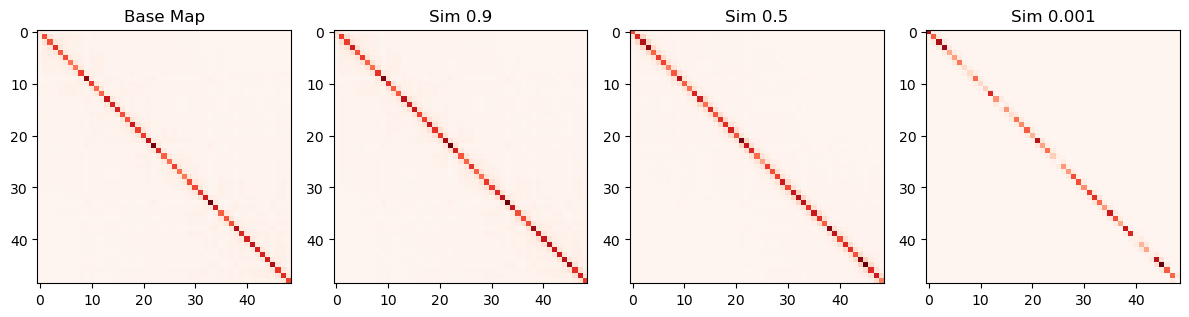

(<Figure size 1200x400 with 4 Axes>,
 array([<Axes: title={'center': 'Base Map'}>,
        <Axes: title={'center': 'Sim 0.9'}>,
        <Axes: title={'center': 'Sim 0.5'}>,
        <Axes: title={'center': 'Sim 0.001'}>], dtype=object))

In [10]:
### Testing Defined Related Map Function ###
clp1_binned = binned_chr1s[9]
similarities = [0.99, 0.9, 0.75, 0.5, 0.25, 0.1, 0.01, 0.001]
clp_related = []

for sim in similarities:
    clp_related.append(generate_related_contact_map(clp1_binned, base_decay=0.75, similarity=sim, seed = 106))

visualize_synthetic_maps([clp1_binned, clp_related[1], clp_related[3], clp_related[7]], ["Base Map", "Sim 0.9", "Sim 0.5", "Sim 0.001"])

It seems like the oringinal function for generating related maps works fine with real data as well.

### Binned at 4 Mb, No Maximum Normalization

In [11]:
### Prepping data for OT ###
# Base map
base_mask = np.triu(clp1_binned, k=1) > 0
base_coords = np.column_stack(np.where(base_mask))
base_values = clp1_binned[base_mask]

# Target maps
coords_list = []
values_list = []
for target in clp_related:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values = values * (base_values.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list.append(coords)
    values_list.append(values)

1572414.0
1572414.0
1572414.0
1572413.9999999998
1572414.0
1572414.0000000002
1572414.0
1572414.0


In [12]:
### Exact OT for all target maps ###
ot_values = []

for coords, values in zip(coords_list, values_list):
    M = ot.dist(base_coords, coords)
    print("Calculated M")
    ot_value = ot.solve(M, base_values, values).value
    print("Calculated value")
    ot_values.append(ot_value)

Calculated M
Calculated value
Calculated M


/opt/anaconda3/envs/hicotenv/lib/python3.13/site-packages/ot/lp/_network_simplex.py:578: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)


Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value


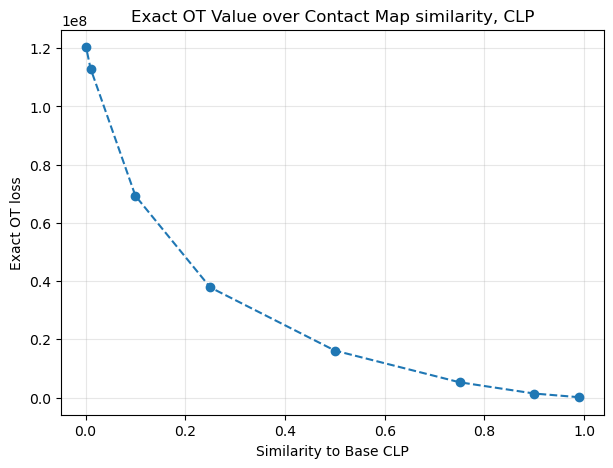

In [13]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(similarities, ot_values, 'o--')
plt.xlabel("Similarity to Base CLP")
plt.ylabel("Exact OT loss")
plt.title("Exact OT Value over Contact Map similarity, CLP")
plt.grid(alpha=0.3)
plt.show()

The results make sense. It seems that the OT loss scales with the numbers in the original dataset, warranting investigation into the nature of normalized data.

### Binned at 4 Mb, Maximum normalized

In [14]:
### Prepping data for OT ###
# Base map normalization
base_values_norm = base_values / base_values.max()

# Target maps
coords_list_norm = []
values_list_norm = []
for target in clp_related:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values = values / values.max()  # Maximum normalizing
    values = values * (base_values_norm.sum() / values.sum()) # Normalizing to ensure equivalent weights
    print(values.sum())
    coords_list_norm.append(coords)
    values_list_norm.append(values)

134.84383843581168
134.84383843581168
134.84383843581168
134.84383843581168
134.84383843581168
134.84383843581168
134.84383843581173
134.84383843581168


In [15]:
### Exact OT for all target maps ###
ot_values_norm = []

for coords, values in zip(coords_list_norm, values_list_norm):
    M = ot.dist(base_coords, coords)
    print("Calculated M")
    ot_value = ot.solve(M, base_values_norm, values).value
    print("Calculated value")
    ot_values_norm.append(ot_value)

Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value


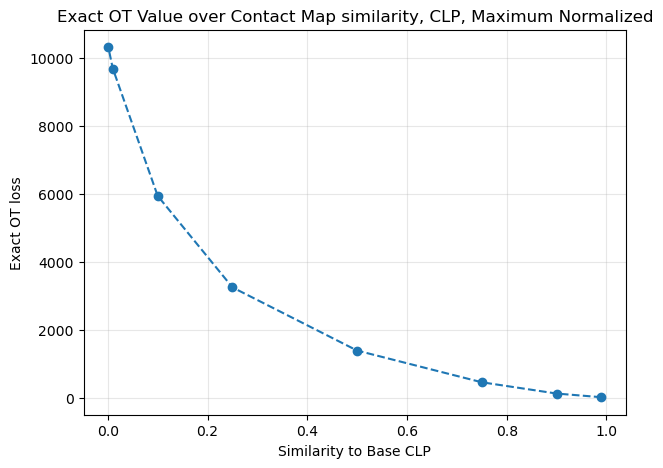

In [16]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(similarities, ot_values_norm, 'o--')
plt.xlabel("Similarity to Base CLP")
plt.ylabel("Exact OT loss")
plt.title("Exact OT Value over Contact Map similarity, CLP, Maximum Normalized")
plt.grid(alpha=0.3)
plt.show()

### Binned at 4 Mb, Normalized to Sum to 1

In [17]:
### Prepping data for OT ###
# Base map normalization + summing to 1
base_values_norm_sum = base_values / base_values.sum()

# Target maps
coords_list_norm_sum = []
values_list_norm_sum = []
for target in clp_related:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values = values / values.sum()
    print(values.sum())
    coords_list_norm_sum.append(coords)
    values_list_norm_sum.append(values)

1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.9999999999999999


In [18]:
### Exact OT for all target maps ###
ot_values_norm_sum = []

for coords, values in zip(coords_list_norm_sum, values_list_norm_sum):
    M = ot.dist(base_coords, coords)
    print("Calculated M")
    ot_value = ot.solve(M, base_values_norm_sum, values).value
    print("Calculated value")
    ot_values_norm_sum.append(ot_value)

Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value


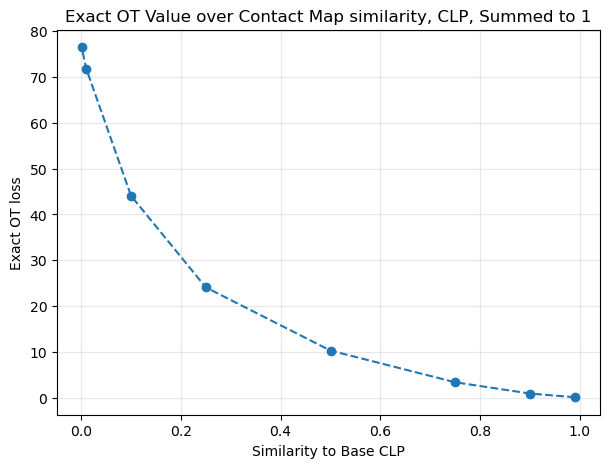

In [19]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(similarities, ot_values_norm_sum, 'o--')
plt.xlabel("Similarity to Base CLP")
plt.ylabel("Exact OT loss")
plt.title("Exact OT Value over Contact Map similarity, CLP, Summed to 1")
plt.grid(alpha=0.3)
plt.show()

## Unbalanced OT

### Decreasing Similarity

#### Binned at 4 Mb, No Maximum Normalization

In [20]:
### Prepping data for OT ###
# Base map
base_values = clp1_binned[base_mask]

# Target maps
coords_list_uot_sim = []
values_list_uot_sim = []
for target in clp_related:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    coords_list_uot_sim.append(coords)
    values_list_uot_sim.append(values)

In [21]:
### Exact OT for all target maps ###
ot_values_uot_sim = []
unbalanced = 5e-1

for coords, values in zip(coords_list_uot_sim, values_list_uot_sim):
    M = ot.dist(base_coords, coords)
    print("Calculated M")
    ot_value = ot.solve(M, base_values, values, unbalanced=unbalanced).value
    print("Calculated value")
    ot_values_uot_sim.append(ot_value)

Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value


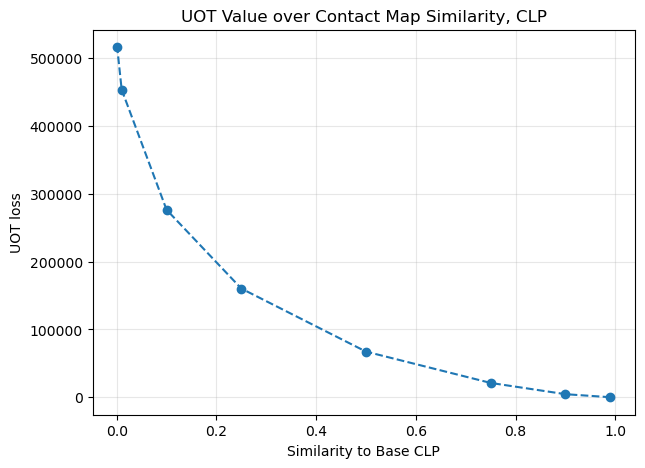

In [22]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(similarities, ot_values_uot_sim, 'o--')
plt.xlabel("Similarity to Base CLP")
plt.ylabel("UOT loss")
plt.title("UOT Value over Contact Map Similarity, CLP")
plt.grid(alpha=0.3)
plt.show()

#### Binned at 4 Mb, Maximum Normalized

In [23]:
### Prepping data for OT ###
# Base map normalization
base_values_norm_uot_sim = base_values / base_values.max()

# Target maps
coords_list_norm_uot_sim = []
values_list_norm_uot_sim = []
for target in clp_related:
    mask = np.triu(target, k=1) > 0
    coords = np.column_stack(np.where(mask))
    values = target[mask]
    values = values / values.max()  # Maximum normalizing
    print(values.sum())
    coords_list_norm_uot_sim.append(coords)
    values_list_norm_uot_sim.append(values)

134.16588685665675
128.15070794336452
107.59818813432327
71.98299144418101
42.89367610886297
30.726985510404184
24.402384816199813
23.800168990283062


In [32]:
print(values_list_norm_uot_sim[0])

[0.4362399  0.10106338 0.0596342  ... 1.         0.2967248  0.8008507 ]


In [24]:
### Exact OT for all target maps ###
ot_values_norm_uot_sim = []

for coords, values in zip(coords_list_norm_uot_sim, values_list_norm_uot_sim):
    M = ot.dist(base_coords, coords)
    print("Calculated M")
    ot_value = ot.solve(M, base_values_norm_uot_sim, values, unbalanced=unbalanced).value
    print("Calculated value")
    ot_values_norm_uot_sim.append(ot_value)

Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value
Calculated M
Calculated value


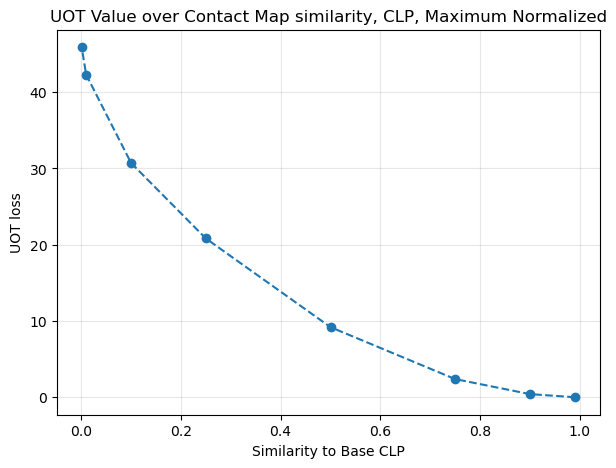

In [25]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(similarities, ot_values_norm_uot_sim, 'o--')
plt.xlabel("Similarity to Base CLP")
plt.ylabel("UOT loss")
plt.title("UOT Value over Contact Map similarity, CLP, Maximum Normalized")
plt.grid(alpha=0.3)
plt.show()

### Increasing Mass Ratios

#### Generating Data

In [26]:
### Multiplying masses
mass_ratio_list = [0.25, 0.75, 1.0, 1.5, 2, 4, 6, 8]
values_list_uot_mass = []

for ratio in mass_ratio_list:
    values = base_values_norm * ratio
    print(values.sum())
    values_list_uot_mass.append(values)

33.71095960895292
101.13287882685877
134.84383843581168
202.26575765371754
269.68767687162335
539.3753537432467
809.0630306148702
1078.7507074864934


#### Binned at 4 Mb

In [27]:
### Exact OT for all target maps ###
ot_values_uot_mass = []
M = ot.dist(base_coords, base_coords)

for values in values_list_uot_mass:
    ot_value = ot.solve(M, base_values_norm, values, unbalanced=unbalanced).value
    print("Calculated value")
    ot_values_uot_mass.append(ot_value)

Calculated value
Calculated value
Calculated value
Calculated value
Calculated value
Calculated value
Calculated value
Calculated value


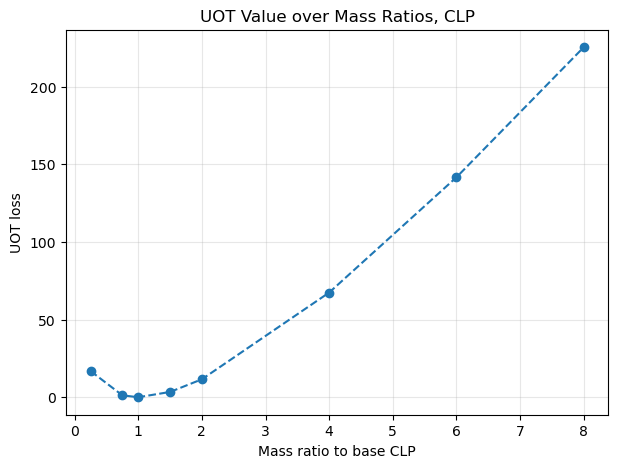

In [28]:
### Visualizing ###
plt.figure(figsize=(7, 5))
plt.plot(mass_ratio_list, ot_values_uot_mass, 'o--')
plt.xlabel("Mass ratio to base CLP")
plt.ylabel("UOT loss")
plt.title("UOT Value over Mass Ratios, CLP")
plt.grid(alpha=0.3)
plt.show()